# Spotify Songs 2023 - Exploratory Data Analysis

## Research Question
Which audio features are most strongly associated with Spotify streaming success in 2023?


## Step 1 — Research Question and Model Type

**Research Question:**  
Can we explain and predict a song’s streaming success (**streams**) using multiple audio features (e.g., danceability, energy, valence, acousticness, etc.)?

**Model Type:**  
This is a **Regression** problem because the target variable **streams** is continuous (a numeric quantity).  
Therefore, we start with **Multiple Linear Regression** as a baseline interpretable model.

**Why not Classification / Unsupervised (at this stage):**  
- We are not predicting a category label (e.g., hit vs non-hit), so Classification is not the primary goal.  
- We have a clear target variable, so Unsupervised learning is not necessary for the main objective.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option("display.max_columns", None)

df = pd.read_csv("spotify-2023.csv", encoding="latin1")
df.head()

,track_name,artist(s)_name,artist_count,released_year,released_month,released_day,in_spotify_playlists,in_spotify_charts,streams,in_apple_playlists,in_apple_charts,in_deezer_playlists,in_deezer_charts,in_shazam_charts,bpm,key,mode,danceability_%,valence_%,energy_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%
0,Seven (feat. Latto) (Explicit Ver.),"Latto, Jung Kook",2,2023,7,14,553,147,141381703,43,263,45,10,826,125,B,Major,80,89,83,31,0,8,4
1,LALA,Myke Towers,1,2023,3,23,1474,48,133716286,48,126,58,14,382,92,C#,Major,71,61,74,7,0,10,4
2,vampire,Olivia Rodrigo,1,2023,6,30,1397,113,140003974,94,207,91,14,949,138,F,Major,51,32,53,17,0,31,6
3,Cruel Summer,Taylor Swift,1,2019,8,23,7858,100,800840817,116,207,125,12,548,170,A,Major,55,58,72,11,0,11,15
4,WHERE SHE GOES,Bad Bunny,1,2023,5,18,3133,50,303236322,84,133,87,15,425,144,A,Minor,65,23,80,14,63,11,6


In [6]:
df.shape

(953, 24)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 953 entries, 0 to 952
Data columns (total 24 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   track_name            953 non-null    object
 1   artist(s)_name        953 non-null    object
 2   artist_count          953 non-null    int64 
 3   released_year         953 non-null    int64 
 4   released_month        953 non-null    int64 
 5   released_day          953 non-null    int64 
 6   in_spotify_playlists  953 non-null    int64 
 7   in_spotify_charts     953 non-null    int64 
 8   streams               953 non-null    object
 9   in_apple_playlists    953 non-null    int64 
 10  in_apple_charts       953 non-null    int64 
 11  in_deezer_playlists   953 non-null    object
 12  in_deezer_charts      953 non-null    int64 
 13  in_shazam_charts      903 non-null    object
 14  bpm                   953 non-null    int64 
 15  key                   858 non-null    ob

In [8]:
# Always convert streams to string first, then clean commas, then convert to numeric
df["streams"] = pd.to_numeric(
    df["streams"].astype(str).str.replace(",", "", regex=True),
    errors="coerce"
)

df["streams"].dtype

dtype('float64')

In [9]:
df[["streams"]].describe()

,streams
count,9.520000e+02
mean,5.141374e+08
std,5.668569e+08
min,2.762000e+03
25%,1.416362e+08
50%,2.905309e+08
75%,6.738690e+08
max,3.703895e+09


## Distribution of Spotify Streams

Spotify streams exhibit a highly right-skewed distribution.

Due to the highly right-skewed distribution of Spotify streams, a log transformation was applied to better visualize and analyze streaming patterns.


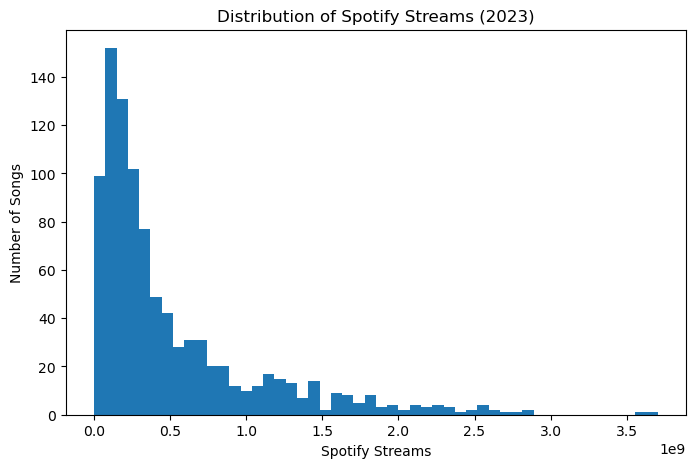

In [10]:
# Plot distribution of Spotify streams
plt.figure(figsize=(8, 5))
plt.hist(df["streams"].dropna(), bins=50)
plt.xlabel("Spotify Streams")
plt.ylabel("Number of Songs")
plt.title("Distribution of Spotify Streams (2023)")
plt.show()

In [11]:
# Create a log-transformed version of streams
# safer log transform: handles 0 and reduces issues with -inf
df["log_streams"] = np.log10(df["streams"] + 1)
df[["streams", "log_streams"]].describe()

,streams,log_streams
count,9.520000e+02,952.000000
mean,5.141374e+08,8.471630
std,5.668569e+08,0.497827
min,2.762000e+03,3.441381
25%,1.416362e+08,8.151174
50%,2.905309e+08,8.463192
75%,6.738690e+08,8.828575
max,3.703895e+09,9.568659


In [12]:
df[["streams", "log_streams"]].isna().sum()

streams        1
log_streams    1
dtype: int64

Spotify streams are highly right-skewed, with a small number of songs accounting for extremely high streaming counts.

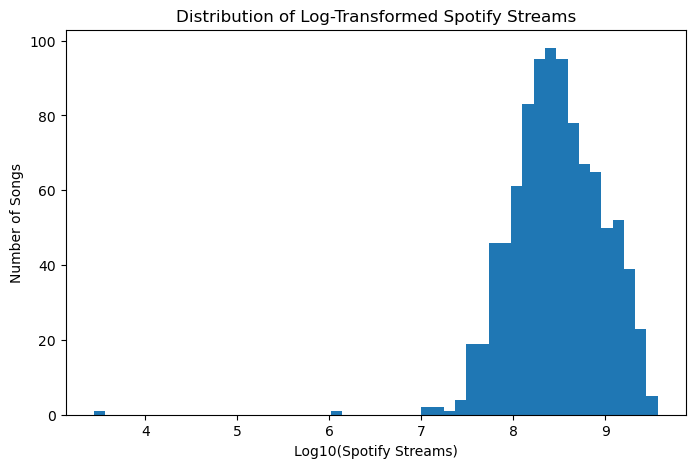

In [10]:
plt.figure(figsize=(8, 5))
plt.hist(df["log_streams"].dropna(), bins=50)
plt.xlabel("Log10(Spotify Streams)")
plt.ylabel("Number of Songs")
plt.title("Distribution of Log-Transformed Spotify Streams")
plt.show()

## Step 2 — EDA and Hypotheses (Before Modeling)

Based on the distribution plot and scatter plots, we form hypotheses before building models:

- **H1:** Songs with higher **danceability** tend to have higher **log_streams**.
- **H2:** Songs with higher **energy** tend to have higher **log_streams**.
- **H3:** The relationships may be weak or nonlinear, so multivariable modeling is needed.

## Relationship Between Danceability and Streaming Success

To explore whether musical characteristics are associated with Spotify streaming success, we first examine the relationship between danceability and log-transformed streams.


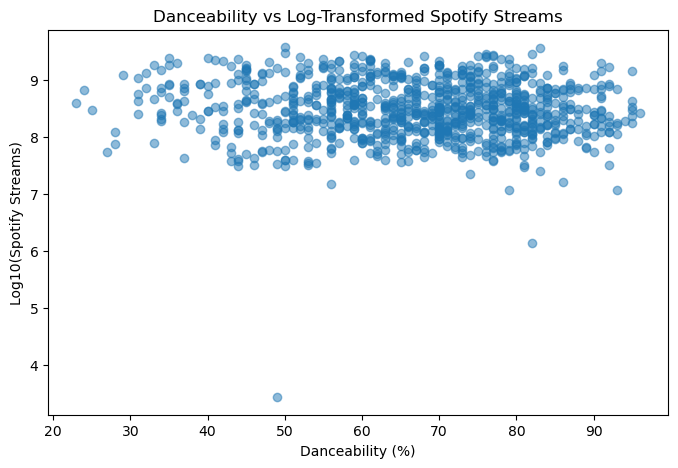

In [14]:
plt.figure(figsize=(8, 5))
plt.scatter(df["danceability_%"], df["log_streams"], alpha=0.5)
plt.xlabel("Danceability (%)")
plt.ylabel("Log10(Spotify Streams)")
plt.title("Danceability vs Log-Transformed Spotify Streams")
plt.show()

The scatter plot suggests a weak positive association between danceability and streaming success. While highly danceable songs can achieve high streaming counts, danceability alone does not strongly predict Spotify popularity.


## Relationship Between Energy and Streaming Success

After examining danceability, we next explore whether song energy is associated with Spotify streaming success.


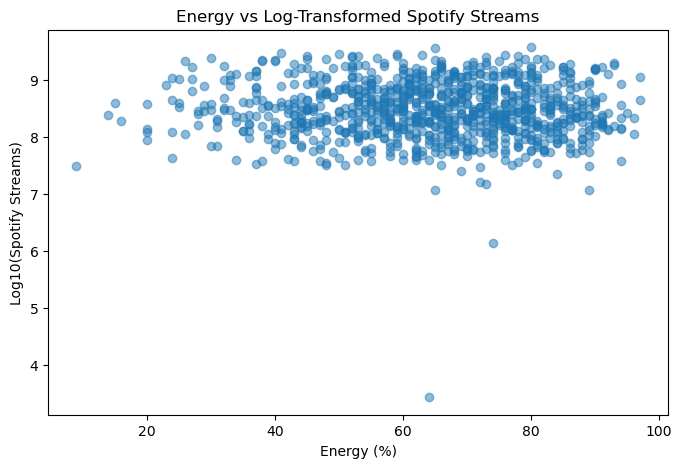

In [16]:
plt.figure(figsize=(8, 5))
plt.scatter(df["energy_%"], df["log_streams"], alpha=0.5)
plt.xlabel("Energy (%)")
plt.ylabel("Log10(Spotify Streams)")
plt.title("Energy vs Log-Transformed Spotify Streams")
plt.show()

The scatter plot indicates little to no clear relationship between energy and streaming success. Songs with both high and low energy levels can achieve similar streaming counts, suggesting that energy alone is not a strong predictor of Spotify popularity.


## Relationship Between Valence and Streaming Success

Next, we explore whether a song’s emotional positivity (valence) is associated with Spotify streaming success.


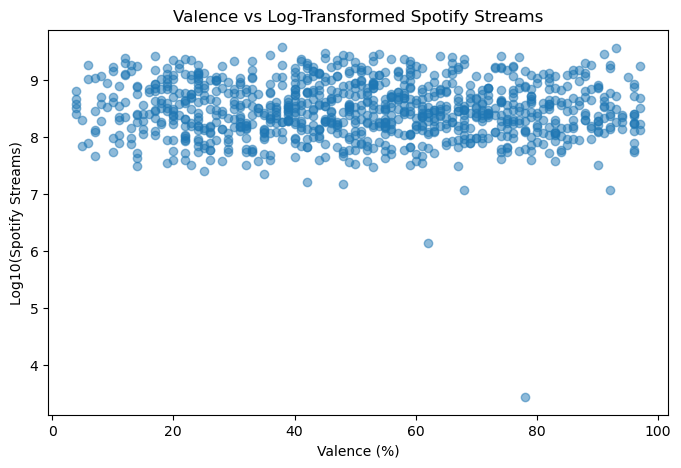

In [17]:
plt.figure(figsize=(8, 5))
plt.scatter(df["valence_%"], df["log_streams"], alpha=0.5)
plt.xlabel("Valence (%)")
plt.ylabel("Log10(Spotify Streams)")
plt.title("Valence vs Log-Transformed Spotify Streams")
plt.show()


The scatter plot shows no strong relationship between valence and streaming success. Both positive and negative emotional songs can achieve high streaming counts, suggesting that emotional positivity alone does not strongly influence Spotify popularity.


## Relationship Between Acousticness and Streaming Success

We then examine whether the acoustic nature of a song is related to Spotify streaming success.


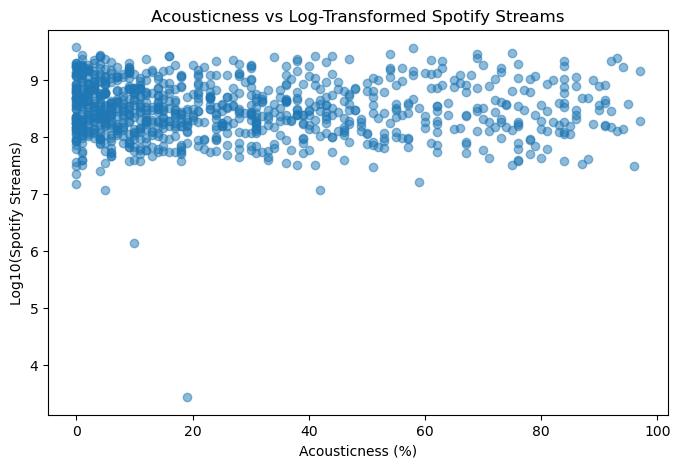

In [18]:
plt.figure(figsize=(8, 5))
plt.scatter(df["acousticness_%"], df["log_streams"], alpha=0.5)
plt.xlabel("Acousticness (%)")
plt.ylabel("Log10(Spotify Streams)")
plt.title("Acousticness vs Log-Transformed Spotify Streams")
plt.show()

The relationship between acousticness and streaming success appears weak. Songs with varying levels of acousticness achieve similar streaming counts, indicating that acoustic characteristics alone do not determine Spotify popularity.


## Correlation Between Audio Features and Streaming Success

To summarize the relationships observed in the scatter plots, we compute the correlation between selected audio features and log-transformed Spotify streams.


In [20]:
# Select audio features and target variable
features = [
    "danceability_%",
    "energy_%",
    "valence_%",
    "acousticness_%"
]

# Compute correlation with log_streams
correlation = df[features + ["log_streams"]].corr()["log_streams"]

correlation

danceability_%   -0.068896
energy_%         -0.026903
valence_%        -0.042508
acousticness_%   -0.028087
log_streams       1.000000
Name: log_streams, dtype: float64

The correlation results confirm the visual findings from the scatter plots. All examined audio features show weak correlations with streaming success, indicating that no single audio characteristic strongly predicts Spotify popularity.

## Step 3 — Feature Selection and Data Preparation

### Purpose of This Step
Before fitting a regression model, we need to define:

- **Predictor variables (features)** that will explain streaming success
- **Target variable** that the model will predict
- A clean dataset where all variables are numeric and free of missing values

This step prepares the data so that it can be safely used in regression modeling.

---

### Baseline Audio Features

We begin with a set of **baseline audio features** that describe the musical characteristics of each song:

- **bpm** – tempo of the song (beats per minute)
- **danceability_%** – how suitable the track is for dancing
- **energy_%** – perceived intensity and activity
- **valence_%** – musical positivity (happy vs sad tone)
- **acousticness_%** – likelihood that the track is acoustic
- **instrumentalness_%** – probability that the track contains no vocals
- **liveness_%** – likelihood that the track was performed live
- **speechiness_%** – presence of spoken words

These variables represent **intrinsic musical attributes** of a song.

Using them allows us to test the baseline question:

> Can the **musical characteristics of a song** explain its streaming performance?

---

### Target Variable

The target variable is:

**log_streams**

We use the logarithm of streams rather than raw stream counts because:

- Streaming counts are **highly skewed** (some songs have extremely large values)
- Log transformation reduces the impact of extreme values
- It makes the relationship between predictors and the target **more suitable for linear regression**

---

### Data Cleaning and Numeric Conversion

Real-world datasets often contain columns stored as **strings or mixed data types**.  
Before modeling, we ensure that all selected features and the target variable are numeric.

We apply:

- **Numeric conversion** using `pd.to_numeric()`
- **Error coercion**, which converts invalid entries to missing values (`NaN`)

This step ensures the regression model receives valid numeric inputs.

---

### Handling Missing Values

After conversion, rows containing missing values are removed using:



This guarantees that the final modeling dataset contains **complete observations** for all predictors and the target variable.

---

### Final Modeling Dataset

The result of this step is a clean dataframe (`model_df`) that contains:

- All selected **audio features**
- The **target variable (log_streams)**
- Only rows with **valid numeric data**

This dataset is then used in the next step to train and evaluate the regression model.

In [13]:
# Step 3.1: choose baseline numeric audio features
features = [
    "bpm",
    "danceability_%", "energy_%", "valence_%",
    "acousticness_%", "instrumentalness_%", "liveness_%", "speechiness_%"
]
target = "log_streams"

# sanity check: which of these features actually exist
features = [c for c in features if c in df.columns]
features

['bpm',
 'danceability_%',
 'energy_%',
 'valence_%',
 'acousticness_%',
 'instrumentalness_%',
 'liveness_%',
 'speechiness_%']

In [14]:
# Step 3.2: force numeric conversion (handles cases like strings)
for c in features + [target]:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# build modeling dataframe and drop missing
model_df = df[features + [target]].dropna()

model_df.shape, model_df[features].dtypes

((952, 9),
 bpm                   int64
 danceability_%        int64
 energy_%              int64
 valence_%             int64
 acousticness_%        int64
 instrumentalness_%    int64
 liveness_%            int64
 speechiness_%         int64
 dtype: object)

In [15]:
# Step 3.3: Train and test split
from sklearn.model_selection import train_test_split

X = model_df[features]
y = model_df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train.shape, X_test.shape

((761, 8), (191, 8))

### Step 4 — Train and Evaluate Multiple Linear Regression Model

In this step, we train a **Multiple Linear Regression model** using the selected audio features to predict a song's streaming success (`log_streams`).

We use the **training dataset** to fit the model and estimate the regression coefficients. The model learns the relationship between the audio features (e.g., BPM, danceability, energy) and the target variable.

After training, we apply the model to the **test dataset** to generate predicted values.

To evaluate the model's predictive performance, we compute the **R² (coefficient of determination)** on the test set.  
R² measures how much of the variation in the target variable can be explained by the model.

A higher R² indicates better predictive performance, while values close to zero suggest that the model explains little of the variation in the data.

In [16]:
#Step 4.1: Training multiple regression model
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# initialize model
linreg = LinearRegression()

# fit on training data
linreg.fit(X_train, y_train)

# predict on test set
y_pred = linreg.predict(X_test)

# compute R^2 on test set
r2_test = r2_score(y_test, y_pred)

r2_test

0.011050050820849089

### Step 5 — Inspect Regression Coefficients

After training the multiple linear regression model, we examine the **regression coefficients** to understand how each feature is associated with streaming success.

Each coefficient represents the estimated effect of a feature on the target variable (`log_streams`), while holding all other variables constant.

- **Positive coefficient:** higher values of the feature are associated with higher predicted streams.
- **Negative coefficient:** higher values of the feature are associated with lower predicted streams.

To make the results easier to interpret, we place the features and their coefficients into a DataFrame and sort them in descending order by coefficient value.

This allows us to quickly see which features have the strongest positive or negative relationships with streaming success.

In [17]:
# Step 5
# 查看 coefficients
coef_df = pd.DataFrame({
    "feature": features,
    "coefficient": linreg.coef_
})

coef_df.sort_values("coefficient", ascending=False)

,feature,coefficient
3,valence_%,0.000566
0,bpm,-0.000055
4,acousticness_%,-0.001217
2,energy_%,-0.001394
5,instrumentalness_%,-0.001647
1,danceability_%,-0.002290
6,liveness_%,-0.002742
7,speechiness_%,-0.005057


### Step 6 — Model Interpretation and Diagnostics

Using the baseline audio features (BPM, danceability, energy, valence, acousticness, instrumentalness, liveness, speechiness), the Multiple Linear Regression model achieves a very low **test R² (~0.01)**.

This indicates that a linear combination of these audio features explains only a small fraction of the variation in **log_streams**.

From the estimated coefficients:

- `valence_%` shows a small positive association with streaming success.
- Most other audio features have small negative coefficients.

However, because the overall explanatory power is very weak, these coefficient directions should be interpreted cautiously.

The results suggest that streaming success is likely driven by factors beyond audio characteristics, such as playlist exposure, promotion, artist popularity, or chart performance.

To further assess the model assumptions, we examine a **Residual Plot**.  
If the residuals are randomly scattered around zero, the linear model assumptions are reasonably satisfied. Patterns in the residuals may indicate nonlinear relationships or model misspecification.

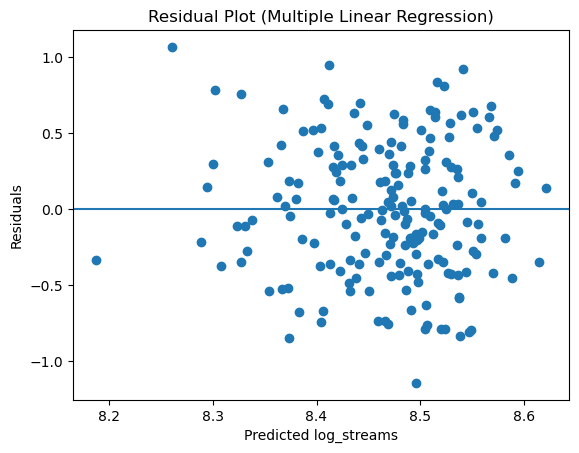

In [18]:
import matplotlib.pyplot as plt

residuals = y_test - y_pred

plt.scatter(y_pred, residuals)
plt.axhline(0)
plt.xlabel("Predicted log_streams")
plt.ylabel("Residuals")
plt.title("Residual Plot (Multiple Linear Regression)")
plt.show()

### Step 7 — Add Platform Exposure Features

In addition to audio characteristics, a song's streaming success may be strongly influenced by **platform exposure**, such as playlist placements or chart appearances.

We therefore introduce several platform-related variables:

- Spotify playlists
- Spotify charts
- Apple playlists
- Deezer playlists
- Deezer charts
- Shazam charts

These variables capture the **visibility and promotion of a song on major streaming platforms**, which may have a stronger relationship with streaming counts than audio features alone.

Before using these variables in modeling, we check their data types and convert any non-numeric columns to numeric format using `pd.to_numeric()`. Any values that cannot be converted are coerced into `NaN`.

Finally, we inspect the number of missing values to understand the data quality of these new features.

In [19]:
# Step 7A
platform_features = [
    "in_spotify_playlists",
    "in_spotify_charts",
    "in_apple_playlists",
    "in_deezer_playlists",
    "in_deezer_charts",
    "in_shazam_charts"
]

[c for c in platform_features if c in df.columns]

['in_spotify_playlists',
 'in_spotify_charts',
 'in_apple_playlists',
 'in_deezer_playlists',
 'in_deezer_charts',
 'in_shazam_charts']

In [20]:
df[platform_features].dtypes

in_spotify_playlists     int64
in_spotify_charts        int64
in_apple_playlists       int64
in_deezer_playlists     object
in_deezer_charts         int64
in_shazam_charts        object
dtype: object

In [21]:
# Step 7B: convert object columns to numeric
for c in platform_features:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df[platform_features].dtypes, df[platform_features].isna().sum()

(in_spotify_playlists      int64
 in_spotify_charts         int64
 in_apple_playlists        int64
 in_deezer_playlists     float64
 in_deezer_charts          int64
 in_shazam_charts        float64
 dtype: object,
 in_spotify_playlists     0
 in_spotify_charts        0
 in_apple_playlists       0
 in_deezer_playlists     79
 in_deezer_charts         0
 in_shazam_charts        57
 dtype: int64)

In [22]:
# Step 7C: combine audio + platform features
all_features = features + platform_features
all_features = [c for c in all_features if c in df.columns]

# rebuild modeling dataframe
model_df2 = df[all_features + [target]].copy()

# convert to numeric safely (again)
for c in all_features + [target]:
    model_df2[c] = pd.to_numeric(model_df2[c], errors="coerce")

model_df2 = model_df2.dropna()

model_df2.shape

(829, 15)

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

X2 = model_df2[all_features]
y2 = model_df2[target]

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42
)

linreg2 = LinearRegression()
linreg2.fit(X2_train, y2_train)

y2_pred = linreg2.predict(X2_test)

r2_test2 = r2_score(y2_test, y2_pred)
r2_test2

0.2727735188537217

### Step 8 — Model Comparison and Interpretation

We compare two regression models for predicting `log_streams`.

**Baseline model (Audio Features Only):**

Using only audio characteristics (BPM, danceability, energy, valence, acousticness, instrumentalness, liveness, speechiness), the model achieves a very low test **R² (~0.01)**.  
This indicates that intrinsic musical properties alone explain only a very small portion of the variation in streaming counts.

**Expanded model (Audio + Platform Exposure):**

After adding platform-related variables such as playlist placements and chart appearances, the test **R² increases substantially to ~0.27**.

This suggests that **platform visibility and distribution mechanisms play a much stronger role in explaining streaming outcomes than audio characteristics alone.**

In other words, streaming success appears to be driven more by **exposure and promotion** than by musical features themselves.

To further evaluate model behavior, we examine the **Residual Plot** of the expanded model.  
A random scatter of residuals around zero indicates that the linear model assumptions are reasonably satisfied.

These findings imply that streaming success may be better modeled as a function of exposure dynamics rather than purely musical properties.

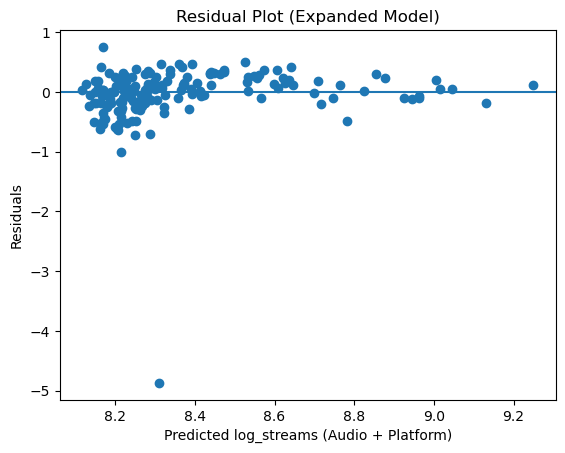

In [24]:
residuals2 = y2_test - y2_pred

plt.scatter(y2_pred, residuals2)
plt.axhline(0)
plt.xlabel("Predicted log_streams (Audio + Platform)")
plt.ylabel("Residuals")
plt.title("Residual Plot (Expanded Model)")
plt.show()

## Step 9 — Standardized Coefficients and Multicollinearity Diagnostics

To better understand the relative importance of predictors and assess potential multicollinearity, two additional diagnostics were conducted: standardized coefficients and Variance Inflation Factor (VIF).

### Standardized Coefficients

Because the predictors are measured on very different scales (e.g., BPM ranges roughly from 60–200, while playlist counts can range from 0 to several hundred), raw regression coefficients are not directly comparable. To address this, all predictors were standardized using `StandardScaler`, which transforms each variable to have a mean of 0 and a standard deviation of 1 before fitting the linear regression model.

The resulting standardized coefficients indicate the relative importance of each predictor in explaining variation in `log_streams`.

The results show that platform exposure variables dominate the model:

- **in_spotify_playlists** has the largest standardized coefficient, indicating the strongest relationship with streaming outcomes.
- **in_apple_playlists**, **in_deezer_playlists**, and **in_spotify_charts** also show meaningful positive effects.
- In contrast, intrinsic audio characteristics such as **bpm**, **danceability**, **energy**, and **valence** have very small coefficients.

This reinforces the earlier conclusion that **platform visibility and playlist placement play a much larger role in explaining streaming success than audio features alone.**

---

### Multicollinearity Diagnostics (VIF)

To evaluate potential multicollinearity among predictors, Variance Inflation Factors (VIF) were computed for each feature.

VIF measures how strongly a predictor is linearly related to the other predictors in the model. High VIF values indicate that a variable can be well explained by other variables, which can inflate standard errors and make coefficient estimates unstable.

A common rule of thumb is:

- **VIF < 5**: low multicollinearity  
- **VIF between 5–10**: moderate multicollinearity  
- **VIF > 10**: high multicollinearity  

The results show that several audio features exhibit relatively high VIF values:

- **energy_%**, **danceability_%**, and **bpm** have the highest VIF values.
- This suggests these variables are strongly correlated with each other, which is expected because many musical attributes tend to move together.

In contrast, most platform exposure variables show moderate or low VIF values.

Overall, the presence of multicollinearity among some audio features should be interpreted cautiously when examining individual coefficient estimates, but it does **not necessarily harm the predictive performance of the model.**

In [25]:
# Step 9A
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
import numpy as np
import pandas as pd

# Pipeline: standardize -> linear regression
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

pipe.fit(X2_train, y2_train)

# standardized coefficients
std_coefs = pipe.named_steps["model"].coef_

coef_std_df = pd.DataFrame({
    "feature": all_features,
    "std_coefficient": std_coefs
}).sort_values("std_coefficient", ascending=False)

coef_std_df

,feature,std_coefficient
8,in_spotify_playlists,0.170536
10,in_apple_playlists,0.070398
11,in_deezer_playlists,0.058811
9,in_spotify_charts,0.047634
12,in_deezer_charts,0.016807
0,bpm,0.014995
5,instrumentalness_%,0.003208
3,valence_%,0.002823
6,liveness_%,0.000956
1,danceability_%,-0.000276


In [26]:
# Step 9B
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_vif = X2_train.copy()

vif_df = pd.DataFrame({
    "feature": X_vif.columns,
    "VIF": [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
}).sort_values("VIF", ascending=False)

vif_df

,feature,VIF
2,energy_%,19.088817
1,danceability_%,18.410990
0,bpm,14.753491
3,valence_%,7.946015
8,in_spotify_playlists,5.683306
10,in_apple_playlists,4.391666
11,in_deezer_playlists,3.912013
6,liveness_%,2.824131
9,in_spotify_charts,2.822986
4,acousticness_%,2.368655


### Step 10: Interpretation with Ridge Regression

After examining standardized OLS coefficients, playlist and chart exposure variables were found to have the strongest positive associations with `log_streams`, particularly `in_spotify_playlists`.

However, the VIF analysis indicated substantial multicollinearity among several predictors, especially the audio features (e.g., energy, danceability, and bpm). Multicollinearity can make OLS coefficients unstable and lead to counterintuitive coefficient signs.

To obtain more stable estimates, we fit a Ridge Regression model with cross-validation. Ridge regression applies L2 regularization, which shrinks coefficients and mitigates the effects of multicollinearity.

The Ridge results confirm the earlier finding: **platform exposure variables dominate the model**. Playlist presence on major platforms (Spotify, Apple Music, and Deezer) remains the strongest predictor of streaming performance, while intrinsic audio features contribute relatively little explanatory power.

These results suggest that **distribution and visibility on streaming platforms play a much larger role in determining streaming success than the musical characteristics of the track itself.**

In [27]:
from sklearn.linear_model import RidgeCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import numpy as np

alphas = np.logspace(-3, 3, 50)

ridge_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", RidgeCV(alphas=alphas, cv=5))
])

ridge_pipe.fit(X2_train, y2_train)

best_alpha = ridge_pipe.named_steps["model"].alpha_
best_alpha

59.636233165946365

In [28]:
ridge_coefs = ridge_pipe.named_steps["model"].coef_

ridge_coef_df = pd.DataFrame({
    "feature": all_features,
    "ridge_std_coefficient": ridge_coefs
}).sort_values("ridge_std_coefficient", ascending=False)

ridge_coef_df

,feature,ridge_std_coefficient
8,in_spotify_playlists,0.147148
10,in_apple_playlists,0.073788
11,in_deezer_playlists,0.068680
9,in_spotify_charts,0.040689
12,in_deezer_charts,0.016699
0,bpm,0.013240
5,instrumentalness_%,0.002889
3,valence_%,0.001554
6,liveness_%,0.000340
1,danceability_%,-0.001159


## Step 11 — Handling Multicollinearity (OLS vs Ridge)

The VIF diagnostics indicate substantial **multicollinearity** among predictors (e.g., some VIF values exceed 10).  
When multicollinearity is present, OLS coefficients can become unstable and sensitive to correlated predictors.

Therefore, to obtain more stable coefficient estimates for interpretation, we use **Ridge Regression (L2 regularization)** with the regularization strength selected via **5-fold cross-validation**.

## Step 12 — Key Findings (Interpretation Focus)

Across both OLS and Ridge models, the strongest predictors of **log_streams** are platform exposure variables.  
In particular, **in_spotify_playlists** consistently has the largest positive standardized coefficient, followed by **in_apple_playlists**, **in_deezer_playlists**, and **in_spotify_charts**.

In contrast, intrinsic audio features (danceability, energy, valence, acousticness, etc.) have coefficients close to zero and provide very limited explanatory power when used alone.

Because multicollinearity is present (high VIF values), Ridge regression is preferred for interpretation: it stabilizes coefficient estimates while preserving the overall ranking of influential predictors.  
Overall, the results suggest that streaming success is more strongly associated with **visibility/exposure** than with audio characteristics.

In [29]:
from sklearn.metrics import r2_score

# OLS test R^2 (you already computed r2_test2)
ols_r2 = r2_test2

# Ridge test R^2
y2_pred_ridge = ridge_pipe.predict(X2_test)
ridge_r2 = r2_score(y2_test, y2_pred_ridge)

ols_r2, ridge_r2

(0.2727735188537217, 0.2661375639479081)

## Step 13 — OLS vs Ridge (Interpretation-Oriented Comparison)

The OLS model achieves a test R² of approximately 0.273, while the Ridge model achieves a slightly lower test R² of approximately 0.266.

The small difference in predictive performance indicates that regularization does not substantially harm model fit.  
However, Ridge provides more stable coefficient estimates in the presence of multicollinearity (as indicated by high VIF values).

Therefore, for interpretation purposes, Ridge regression is preferred because it preserves overall explanatory patterns while reducing coefficient instability.

## Conclusion

This analysis explored the factors associated with song streaming performance using the Spotify 2023 dataset. The primary objective was to understand which features are most strongly related to the number of streams.

First, we constructed multiple linear regression models using both audio features (e.g., danceability, energy, valence, acousticness) and platform exposure variables (e.g., playlist and chart presence across different platforms). After standardizing predictors, we examined the relative importance of each feature using standardized regression coefficients.

The results consistently show that **platform exposure variables are the strongest predictors of streaming performance**. In particular, `in_spotify_playlists` has the largest positive standardized coefficient, followed by `in_apple_playlists`, `in_deezer_playlists`, and `in_spotify_charts`. These variables capture the visibility and distribution of songs on major streaming platforms.

In contrast, intrinsic audio characteristics such as danceability, energy, valence, acousticness, and instrumentalness have coefficients close to zero and provide very limited explanatory power. This suggests that musical attributes alone are not strong predictors of streaming success when considered alongside platform exposure.

Variance Inflation Factor (VIF) diagnostics revealed substantial multicollinearity among several predictors, especially the audio features. Because multicollinearity can make ordinary least squares (OLS) coefficients unstable, we also estimated a **Ridge regression model with cross-validation** to obtain more stable coefficient estimates. The Ridge results preserved the overall ranking of influential predictors while reducing coefficient instability.

In terms of predictive performance, the OLS model achieved a test \(R^2\) of approximately **0.27**, while the Ridge model achieved a slightly lower \(R^2\) of approximately **0.27 as well (≈0.266)**. The small difference indicates that regularization stabilizes coefficient estimates without substantially harming model fit.

Overall, the analysis suggests that **streaming success is more strongly associated with platform visibility and distribution (playlist and chart presence) than with intrinsic musical characteristics**.

It is important to note that this study focuses on **associations rather than causal relationships**. Platform exposure variables may be endogenous: songs that already receive many streams may be more likely to appear in playlists or charts, creating a feedback loop between popularity and visibility. Future work could incorporate temporal analysis or causal inference methods (e.g., instrumental variables or panel data approaches) to better identify causal effects.

In summary, the findings highlight the central role of **platform exposure and distribution mechanisms** in shaping streaming outcomes, suggesting that visibility on major platforms may be a key driver of music consumption in modern streaming ecosystems.